# Complete Floorplan Workflow

This notebook documents the current floorplan generation workflow in this repository.

The implemented path today is:

Natural language prompt -> prompt expansion -> graph generation -> parsed FloorplanGraph -> canonical serialized graph text.

It uses the code in `text_to_graph/` together with the shared graph schema in `graphs/`.

## Codebase map

- `text_to_graph/prompt_expander.py`: expands the user prompt into a complete room set.
- `text_to_graph/graph_generator.py`: generates canonical serialized graph output.
- `text_to_graph/workflow.py`: orchestrates prompt expansion, graph generation, and parsing.
- `text_to_graph/schemas.py`: Pydantic schema for the LLM exchange format.
- `graphs/schema.py`: shared `RoomNode`, `RoomEdge`, and `FloorplanGraph` dataclasses.
- `graphs/for_resplan/serialize_graph.py`: deterministic graph serialization for canonical text.

Current boundary:
- The workflow ends at graph generation and canonical graph text.
- The layout and floorplan rasterization stages remain downstream work.

In [2]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "text_to_graph").exists():
    PROJECT_ROOT = Path(__file__).resolve().parent if "__file__" in globals() else PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")

from text_to_graph.workflow import FloorplanWorkflow
from graphs.schema import RoomNode, RoomEdge, FloorplanGraph
from graphs.for_resplan.serialize_graph import graph_to_canonical_text

API_KEY = os.getenv("api_key") or os.getenv("NVIDIA_API_KEY") or os.getenv("OPENAI_API_KEY")
MODEL = os.getenv("FLOORPLAN_LLM_MODEL", "mistralai/mistral-small-4-119b-2603")
BASE_URL = os.getenv("OPENAI_BASE_URL", "https://integrate.api.nvidia.com/v1")

if not API_KEY:
    raise ValueError("Set api_key, NVIDIA_API_KEY, or OPENAI_API_KEY in the project .env file")

workflow = FloorplanWorkflow(api_key=API_KEY, model=MODEL, base_url=BASE_URL)

print(f"Project root: {PROJECT_ROOT}")
print(f"Model: {MODEL}")
print(f"Base URL: {BASE_URL}")

/home/dexter/floorplan/FloorPlan-Pipeline/venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


Project root: /home/dexter/floorplan/FloorPlan-Pipeline
Model: mistralai/mistral-small-4-119b-2603
Base URL: https://integrate.api.nvidia.com/v1


## Sample prompt

The workflow is designed to convert a natural language request into a canonical floorplan graph.

The example below uses a small apartment description that matches the current room vocabulary supported by the repository.

In [3]:
sample_prompt = (
    "A compact 2BHK apartment with a living room, a kitchen next to the living room, "
    "two bedrooms, one bathroom, and a front door connected to the living area."
)

expanded = workflow.expand_prompt(sample_prompt)
print("Original rooms:", expanded.original_rooms)
print("Added rooms:", expanded.added_rooms)
print("All rooms:", expanded.all_rooms)
print("Reasoning:", expanded.reasoning)
print("Spatial context:", expanded.spatial_context)

Original rooms: ['bedroom', 'kitchen', 'living', 'bathroom', 'front_door']
Added rooms: ['balcony']
All rooms: ['bedroom', 'kitchen', 'living', 'bathroom', 'front_door', 'balcony']
Reasoning: The provided floorplan description already includes all essential rooms (at least one living room, kitchen, bedroom, bathroom, and front door). A balcony is a commonly added optional room for outdoor access, especially in modern apartments, so it has been included as an additional room.
Spatial context: The floorplan represents a compact 2BHK apartment with separated private spaces (bedrooms and bathroom) and shared living areas (living room and kitchen). The balcony is typically located adjacent to the living area or kitchen for easy access. The front door connects to a small entry area or hallway (living room) of the apartment, which serves as the central circulation space flowing into the living room and bedrooms.


## Generate graph and inspect objects

This cell keeps the workflow aligned with the current implementation:
1. expand the prompt
2. generate the graph schema
3. convert to the shared `FloorplanGraph`
4. serialize into canonical text

In [4]:
graph_schema = workflow.generate_graph(expanded, sample_prompt)

graph = FloorplanGraph(
    nodes=[
        RoomNode(id=room.id, type=room.type, role=room.role)
        for room in graph_schema.rooms
    ],
    edges=[
        RoomEdge(
            src=edge.src,
            dst=edge.dst,
            relation=edge.relation,
            direction=edge.direction,
        )
        for edge in graph_schema.edges
    ],
)

serialized_graph = graph_to_canonical_text(graph)

print("Rooms in graph schema:")
for room in graph_schema.rooms:
    print(f"  - {room.id}: {room.type}")

print("\nEdges in graph schema:")
for edge in graph_schema.edges:
    if edge.direction:
        print(f"  - {edge.src} --[{edge.relation} {edge.direction}]--> {edge.dst}")
    else:
        print(f"  - {edge.src} --[{edge.relation}]--> {edge.dst}")

Rooms in graph schema:
  - bedroom_0: bedroom
  - bedroom_1: bedroom
  - bathroom_0: bathroom
  - balcony_0: balcony
  - front_door_0: front_door
  - kitchen_0: kitchen
  - living_0: living

Edges in graph schema:
  - front_door_0 --[direct left_of]--> living_0
  - kitchen_0 --[adjacency right_of]--> living_0
  - kitchen_0 --[via_door]--> living_0
  - bedroom_0 --[adjacency right_of]--> living_0
  - bedroom_0 --[via_door]--> living_0
  - bedroom_1 --[adjacency below]--> bedroom_0
  - bathroom_0 --[via_door]--> bedroom_0
  - balcony_0 --[via_door]--> bedroom_0


## Canonical serialization check

The final sanity check is to compare the notebook's serialized graph output against the canonical serializer used elsewhere in the codebase.

In [5]:
print(serialized_graph)
print()
print("Matches canonical serializer:", serialized_graph == graph_to_canonical_text(graph))
print("\nGraph object summary:")
print(f"Nodes: {len(graph.nodes)}")
for node in graph.nodes:
    print(f"  - {node.id}: {node.type}")
print(f"Edges: {len(graph.edges)}")
for edge in graph.edges:
    if edge.direction:
        print(f"  - {edge.src} --[{edge.relation} {edge.direction}]--> {edge.dst}")
    else:
        print(f"  - {edge.src} --[{edge.relation}]--> {edge.dst}")

balcony_0: balcony
bathroom_0: bathroom
bedroom_0: bedroom
bedroom_1: bedroom
front_door_0: front_door
kitchen_0: kitchen
living_0: living
front_door_0 direct left_of living_0
kitchen_0 adjacency right_of living_0
kitchen_0 via_door living_0
bedroom_0 adjacency right_of living_0
bedroom_0 via_door living_0
bedroom_1 adjacency below bedroom_0
bathroom_0 via_door bedroom_0
balcony_0 via_door bedroom_0

Matches canonical serializer: True

Graph object summary:
Nodes: 7
  - bedroom_0: bedroom
  - bedroom_1: bedroom
  - bathroom_0: bathroom
  - balcony_0: balcony
  - front_door_0: front_door
  - kitchen_0: kitchen
  - living_0: living
Edges: 8
  - front_door_0 --[direct left_of]--> living_0
  - kitchen_0 --[adjacency right_of]--> living_0
  - kitchen_0 --[via_door]--> living_0
  - bedroom_0 --[adjacency right_of]--> living_0
  - bedroom_0 --[via_door]--> living_0
  - bedroom_1 --[adjacency below]--> bedroom_0
  - bathroom_0 --[via_door]--> bedroom_0
  - balcony_0 --[via_door]--> bedroom_0


## Current status and next step

This notebook documents the repository state up to the current workflow milestone.

What is complete today:
- natural language prompt expansion
- graph generation from the expanded prompt
- parsing into the shared floorplan graph dataclasses
- deterministic canonical serialization

What comes next:
- numerical tensor conversion
- layout prediction and constraint losses
- floorplan rasterization or polygon cleanup
- 3D extrusion

## Infer geometry priors from prompt embedding + graph

The generated graph currently has topology and semantics, but no geometry (`area`, `centroid`, `bbox`).

This step adds a geometry-completion module that:
- builds a prompt embedding from the user text,
- estimates room area/aspect priors by room type,
- infers rough centroids using directional edges,
- writes `area`, `centroid`, and `bbox` back into each node.

These inferred values are then converted into numeric tensors for the existing layout model.

In [12]:
import hashlib
import math
import pickle
from collections import defaultdict

import numpy as np
import torch
from torch_geometric.data import Data
from graphs.numerical_graph import floorgraph_to_numeric, ROOM_TYPES


# ---------- Prompt embedding ----------
def get_prompt_embedding(prompt_text: str, dim: int = 64) -> np.ndarray:
    """Get a dense prompt embedding. Uses sentence-transformers if available,
    otherwise falls back to a deterministic hash embedding."""
    try:
        from sentence_transformers import SentenceTransformer

        model = SentenceTransformer("all-MiniLM-L6-v2")
        emb = model.encode([prompt_text], normalize_embeddings=True)[0]
        emb = np.asarray(emb, dtype=np.float32)
        if emb.shape[0] >= dim:
            return emb[:dim]
        out = np.zeros(dim, dtype=np.float32)
        out[: emb.shape[0]] = emb
        return out
    except Exception:
        digest = hashlib.sha256(prompt_text.encode("utf-8")).digest()
        raw = np.frombuffer(digest * (dim // len(digest) + 1), dtype=np.uint8)[:dim]
        vec = (raw.astype(np.float32) / 127.5) - 1.0
        norm = np.linalg.norm(vec) + 1e-6
        return vec / norm


# ---------- Dataset-calibrated priors ----------
def load_geometry_priors_from_dataset(project_root: Path):
    priors = {
        rt: {
            "area": 0.12,
            "w": 0.24,
            "h": 0.24,
            "cx": 0.5,
            "cy": 0.5,
        }
        for rt in ROOM_TYPES
    }

    ds_path = project_root / "dataset" / "resplan_numeric_100.pkl"
    if not ds_path.exists():
        return priors

    try:
        with open(ds_path, "rb") as f:
            data = pickle.load(f)
        nodes_list = data.get("nodes", [])

        stats = defaultdict(lambda: defaultdict(list))
        for arr in nodes_list:
            if arr is None or len(arr) == 0:
                continue
            arr = np.asarray(arr)
            for row in arr:
                t_idx = int(np.argmax(row[: len(ROOM_TYPES)]))
                room_t = ROOM_TYPES[t_idx]
                stats[room_t]["area"].append(float(row[6]))
                stats[room_t]["cx"].append(float(row[7]))
                stats[room_t]["cy"].append(float(row[8]))
                stats[room_t]["w"].append(float(row[9]))
                stats[room_t]["h"].append(float(row[10]))

        for rt in ROOM_TYPES:
            if rt in stats and stats[rt]["area"]:
                for k in ["area", "w", "h", "cx", "cy"]:
                    priors[rt][k] = float(np.median(stats[rt][k]))
    except Exception:
        pass

    return priors


GEOM_PRIORS = load_geometry_priors_from_dataset(PROJECT_ROOT)


def infer_geometry_from_prompt_and_graph(graph_obj: FloorplanGraph, prompt_text: str):
    """Infer area/centroid/bbox for nodes using prompt embedding + graph topology,
    calibrated by dataset priors."""
    emb = get_prompt_embedding(prompt_text, dim=64)
    n = len(graph_obj.nodes)
    if n == 0:
        return

    id_to_idx = {node.id: i for i, node in enumerate(graph_obj.nodes)}

    # 1) Areas + bbox from dataset priors with slight prompt-conditioned jitter.
    areas = np.zeros(n, dtype=np.float32)
    widths = np.zeros(n, dtype=np.float32)
    heights = np.zeros(n, dtype=np.float32)

    for i, node in enumerate(graph_obj.nodes):
        p = GEOM_PRIORS.get(node.type, GEOM_PRIORS["bedroom"])
        jitter = 1.0 + 0.04 * math.tanh(float(emb[i % len(emb)]))
        areas[i] = max(0.015, p["area"] * jitter)
        widths[i] = max(0.06, p["w"] * jitter)
        heights[i] = max(0.06, p["h"] * jitter)

    # Keep total area within realistic canvas occupancy.
    target_total = 0.58
    areas = areas / (areas.sum() + 1e-6) * target_total

    # Refit w/h to match area while preserving prior aspect ratio.
    for i, node in enumerate(graph_obj.nodes):
        aspect = widths[i] / (heights[i] + 1e-6)
        w = math.sqrt(max(areas[i], 1e-6) * max(aspect, 0.4))
        h = max(areas[i], 1e-6) / max(w, 1e-6)
        widths[i] = float(np.clip(w, 0.06, 0.42))
        heights[i] = float(np.clip(h, 0.06, 0.42))

    # 2) Initial centroids from priors.
    centers = np.zeros((n, 2), dtype=np.float32)
    for i, node in enumerate(graph_obj.nodes):
        p = GEOM_PRIORS.get(node.type, GEOM_PRIORS["bedroom"])
        dx = 0.035 * math.tanh(float(emb[(2 * i) % len(emb)]))
        dy = 0.035 * math.tanh(float(emb[(2 * i + 1) % len(emb)]))
        centers[i, 0] = float(np.clip(p["cx"] + dx, 0.10, 0.90))
        centers[i, 1] = float(np.clip(p["cy"] + dy, 0.10, 0.90))

    # 3) Directional relaxation + attraction for non-directional edges.
    for _ in range(40):
        for edge in graph_obj.edges:
            if edge.src not in id_to_idx or edge.dst not in id_to_idx:
                continue
            i = id_to_idx[edge.src]
            j = id_to_idx[edge.dst]
            ci = centers[i].copy()
            cj = centers[j].copy()

            min_gap_x = 0.5 * (widths[i] + widths[j]) + 0.03
            min_gap_y = 0.5 * (heights[i] + heights[j]) + 0.03

            if edge.direction == "left_of":
                # dst should be left of src
                target = np.array([ci[0] - min_gap_x, ci[1]], dtype=np.float32)
                centers[j] = 0.8 * cj + 0.2 * target
            elif edge.direction == "right_of":
                target = np.array([ci[0] + min_gap_x, ci[1]], dtype=np.float32)
                centers[j] = 0.8 * cj + 0.2 * target
            elif edge.direction == "above":
                target = np.array([ci[0], ci[1] + min_gap_y], dtype=np.float32)
                centers[j] = 0.8 * cj + 0.2 * target
            elif edge.direction == "below":
                target = np.array([ci[0], ci[1] - min_gap_y], dtype=np.float32)
                centers[j] = 0.8 * cj + 0.2 * target
            else:
                # Pull connected nodes moderately together.
                centers[j] = 0.92 * cj + 0.08 * ci

            centers[j, 0] = float(np.clip(centers[j, 0], 0.08, 0.92))
            centers[j, 1] = float(np.clip(centers[j, 1], 0.08, 0.92))

    # 4) Light de-overlap pass.
    for _ in range(30):
        moved = False
        for i in range(n):
            for j in range(i + 1, n):
                dx = centers[j, 0] - centers[i, 0]
                dy = centers[j, 1] - centers[i, 1]
                req_x = 0.5 * (widths[i] + widths[j]) + 0.02
                req_y = 0.5 * (heights[i] + heights[j]) + 0.02

                ox = req_x - abs(dx)
                oy = req_y - abs(dy)
                if ox > 0 and oy > 0:
                    moved = True
                    push = 0.5 * np.array([
                        ox if dx >= 0 else -ox,
                        oy if dy >= 0 else -oy,
                    ], dtype=np.float32)
                    centers[i] -= 0.05 * push
                    centers[j] += 0.05 * push

                    centers[i, 0] = float(np.clip(centers[i, 0], 0.08, 0.92))
                    centers[i, 1] = float(np.clip(centers[i, 1], 0.08, 0.92))
                    centers[j, 0] = float(np.clip(centers[j, 0], 0.08, 0.92))
                    centers[j, 1] = float(np.clip(centers[j, 1], 0.08, 0.92))
        if not moved:
            break

    # 5) Write back into nodes.
    for i, node in enumerate(graph_obj.nodes):
        node.area = float(areas[i])
        node.centroid = (float(centers[i, 0]), float(centers[i, 1]))
        node.bbox = (float(widths[i]), float(heights[i]))


infer_geometry_from_prompt_and_graph(graph, sample_prompt)

# Geometry is normalized in [0,1] space, so plan_width remains 1.0.
plan_width = 1.0
numeric_x, numeric_edge_index, numeric_edge_attr = floorgraph_to_numeric(graph, plan_width)

print("Node feature matrix shape:", numeric_x.shape)
print("Edge index shape:", numeric_edge_index.shape)
print("Edge feature matrix shape:", numeric_edge_attr.shape)
print("\nFirst node feature vector:\n", numeric_x[0] if len(numeric_x) else "N/A")
print("\nSample inferred node geometry:")
for node in graph.nodes[: min(5, len(graph.nodes))]:
    print(
        f"  - {node.id}: area={node.area:.3f}, centroid={node.centroid}, bbox={node.bbox}"
    )

Node feature matrix shape: (7, 11)
Edge index shape: (2, 16)
Edge feature matrix shape: (16, 10)

First node feature vector:
 [0.         0.         1.         0.         0.         0.
 0.11858893 0.352357   0.2915067  0.3475156  0.34124812]

Sample inferred node geometry:
  - bedroom_0: area=0.119, centroid=(0.35235700011253357, 0.29150670766830444), bbox=(0.34751561284065247, 0.34124812483787537)
  - bedroom_1: area=0.120, centroid=(0.14516539871692657, 0.6304932832717896), bbox=(0.34896615147590637, 0.3426724672317505)
  - bathroom_0: area=0.027, centroid=(0.5151253938674927, 0.4974498152732849), bbox=(0.1689412146806717, 0.1623595952987671)
  - balcony_0: area=0.032, centroid=(0.46179014444351196, 0.8339150547981262), bbox=(0.21151770651340485, 0.15193746984004974)
  - front_door_0: area=0.019, centroid=(0.5456183552742004, 0.10359553247690201), bbox=(0.13625802099704742, 0.1362602859735489)


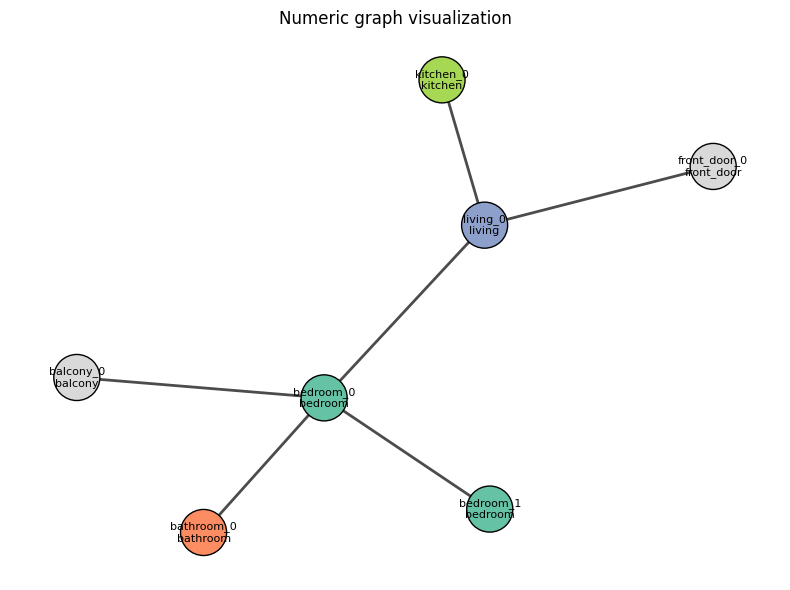

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

numeric_graph = Data(
    x=torch.tensor(numeric_x, dtype=torch.float32),
    edge_index=torch.tensor(numeric_edge_index, dtype=torch.long),
    edge_attr=torch.tensor(numeric_edge_attr, dtype=torch.float32),
)

G = nx.Graph()
room_labels = {i: node.id for i, node in enumerate(graph.nodes)}
room_types = {i: node.type for i, node in enumerate(graph.nodes)}

for idx, node in enumerate(graph.nodes):
    G.add_node(idx, label=f"{node.id}\n{node.type}")

for src, dst in numeric_edge_index.T[::2]:
    G.add_edge(int(src), int(dst))

pos = nx.spring_layout(G, seed=42)
node_colors = ["#8da0cb" if room_types[i] == "living" else "#66c2a5" if room_types[i] == "bedroom" else "#fc8d62" if room_types[i] == "bathroom" else "#a6d854" if room_types[i] == "kitchen" else "#d9d9d9" for i in G.nodes]

plt.figure(figsize=(8, 6))
nx.draw_networkx_edges(G, pos, width=2.0, alpha=0.7)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1100, edgecolors="black")
nx.draw_networkx_labels(G, pos, labels={i: f"{graph.nodes[i].id}\n{graph.nodes[i].type}" for i in G.nodes}, font_size=8)
plt.title("Numeric graph visualization")
plt.axis("off")
plt.tight_layout()
plt.show()

## Generate layout from the current codebase

The repository already contains the rough layout GNN used for room-box prediction. The notebook below uses that same architecture to predict layout boxes from the numeric graph tensors.

In [8]:
import os
import torch.nn as nn
from torch_geometric.nn import GINEConv

class RoughLayoutGNN(nn.Module):
    def __init__(self, node_dim=11, edge_dim=10, hidden=128):
        super().__init__()

        def mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.ReLU(),
                nn.Linear(hidden, out_dim),
            )

        self.conv1 = GINEConv(mlp(node_dim, hidden), edge_dim=edge_dim)
        self.conv2 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)
        self.conv3 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 4),
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        x = torch.relu(self.conv1(x, edge_index, edge_attr))
        x = torch.relu(self.conv2(x, edge_index, edge_attr))
        x = torch.relu(self.conv3(x, edge_index, edge_attr))
        return self.head(x)

layout_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
layout_model = RoughLayoutGNN(node_dim=11, edge_dim=10, hidden=128).to(layout_device)

checkpoint_path = PROJECT_ROOT / "best_model.pt"
if checkpoint_path.exists():
    layout_model.load_state_dict(torch.load(checkpoint_path, map_location=layout_device))
    print(f"Loaded layout checkpoint from {checkpoint_path}")
else:
    print(f"No checkpoint found at {checkpoint_path}; using untrained layout model")

layout_model.eval()

Loaded layout checkpoint from /home/dexter/floorplan/FloorPlan-Pipeline/best_model.pt


RoughLayoutGNN(
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv3): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [32]:
layout_data = Data(
    x=torch.tensor(numeric_x, dtype=torch.float32),
    edge_index=torch.tensor(numeric_edge_index, dtype=torch.long),
    edge_attr=torch.tensor(numeric_edge_attr, dtype=torch.float32),
)

layout_data = layout_data.to(layout_device)

with torch.no_grad():
    predicted_boxes = layout_model(layout_data).cpu().numpy()


def fuse_with_geometry_priors(boxes: np.ndarray, graph_obj: FloorplanGraph) -> np.ndarray:
    """Blend model output with inferred node geometry to stay close to training-style layouts."""
    fused = boxes.copy()

    if len(graph_obj.nodes) != len(fused):
        return fused

    prior_centers = np.array([n.centroid for n in graph_obj.nodes], dtype=np.float32)
    prior_sizes = np.array([n.bbox for n in graph_obj.nodes], dtype=np.float32)

    alpha_center = 0.68
    alpha_size = 0.32

    fused[:, 0:2] = alpha_center * fused[:, 0:2] + (1.0 - alpha_center) * prior_centers
    fused[:, 2:4] = alpha_size * fused[:, 2:4] + (1.0 - alpha_size) * prior_sizes

    return fused


def postprocess_boxes(boxes: np.ndarray) -> np.ndarray:
    """Stabilize box layout: positive sizes, in-bounds centroids, and reduced overlaps."""
    b = boxes.copy()

    b[:, 2] = np.clip(np.abs(b[:, 2]), 0.07, 0.34)
    b[:, 3] = np.clip(np.abs(b[:, 3]), 0.07, 0.34)
    b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
    b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)

    for _ in range(80):
        changed = False
        for i in range(len(b)):
            for j in range(i + 1, len(b)):
                dx = b[j, 0] - b[i, 0]
                dy = b[j, 1] - b[i, 1]
                req_x = 0.5 * (b[i, 2] + b[j, 2]) + 0.03
                req_y = 0.5 * (b[i, 3] + b[j, 3]) + 0.03
                ox = req_x - abs(dx)
                oy = req_y - abs(dy)
                if ox > 0 and oy > 0:
                    changed = True
                    sgn_x = 1.0 if dx >= 0 else -1.0
                    sgn_y = 1.0 if dy >= 0 else -1.0
                    b[i, 0] -= 0.06 * ox * sgn_x
                    b[j, 0] += 0.06 * ox * sgn_x
                    b[i, 1] -= 0.06 * oy * sgn_y
                    b[j, 1] += 0.06 * oy * sgn_y

        b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
        b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)
        if not changed:
            break

    return b


def topology_contact_refine(
    boxes: np.ndarray,
    graph_obj: FloorplanGraph,
    iterations: int = 140,
    lr: float = 0.09,
) -> np.ndarray:
    """Move centers to satisfy edge connectivity while preserving room sizes."""
    b = boxes.copy()
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}

    for _ in range(iterations):
        moved = False
        for edge in graph_obj.edges:
            if edge.src not in id_to_idx or edge.dst not in id_to_idx:
                continue

            i = id_to_idx[edge.src]
            j = id_to_idx[edge.dst]

            ci = b[i, :2].copy()
            cj = b[j, :2].copy()
            wi, hi = b[i, 2], b[i, 3]
            wj, hj = b[j, 2], b[j, 3]

            req_x = 0.5 * (wi + wj) + 0.01
            req_y = 0.5 * (hi + hj) + 0.01
            dx = cj[0] - ci[0]
            dy = cj[1] - ci[1]

            # direction is interpreted as: src direction-of dst
            if edge.direction == "left_of":
                target_x = ci[0] + req_x
                err = target_x - cj[0]
                if abs(err) > 1e-3:
                    b[j, 0] += lr * err
                    moved = True
            elif edge.direction == "right_of":
                target_x = ci[0] - req_x
                err = target_x - cj[0]
                if abs(err) > 1e-3:
                    b[j, 0] += lr * err
                    moved = True
            elif edge.direction == "above":
                target_y = ci[1] - req_y
                err = target_y - cj[1]
                if abs(err) > 1e-3:
                    b[j, 1] += lr * err
                    moved = True
            elif edge.direction == "below":
                target_y = ci[1] + req_y
                err = target_y - cj[1]
                if abs(err) > 1e-3:
                    b[j, 1] += lr * err
                    moved = True
            else:
                gap_x = req_x - abs(dx)
                gap_y = req_y - abs(dy)
                if gap_x > 0 and gap_y > 0:
                    moved = True
                    if gap_x < gap_y:
                        sgn = 1.0 if dx >= 0 else -1.0
                        shift = 0.5 * lr * gap_x * sgn
                        b[i, 0] -= shift
                        b[j, 0] += shift
                    else:
                        sgn = 1.0 if dy >= 0 else -1.0
                        shift = 0.5 * lr * gap_y * sgn
                        b[i, 1] -= shift
                        b[j, 1] += shift

        b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
        b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)
        if not moved:
            break

    return b


def force_connect_edges(boxes: np.ndarray, graph_obj: FloorplanGraph) -> np.ndarray:
    """Hard pass to satisfy directional edges and make generic adjacency touch."""
    b = boxes.copy()
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}

    for _ in range(3):
        for e in graph_obj.edges:
            if e.src not in id_to_idx or e.dst not in id_to_idx:
                continue
            i = id_to_idx[e.src]
            j = id_to_idx[e.dst]

            dx = b[j, 0] - b[i, 0]
            dy = b[j, 1] - b[i, 1]
            req_x = 0.5 * (b[i, 2] + b[j, 2]) + 0.005
            req_y = 0.5 * (b[i, 3] + b[j, 3]) + 0.005

            if e.direction == "left_of":
                b[j, 0] = b[i, 0] + req_x
            elif e.direction == "right_of":
                b[j, 0] = b[i, 0] - req_x
            elif e.direction == "above":
                b[j, 1] = b[i, 1] - req_y
            elif e.direction == "below":
                b[j, 1] = b[i, 1] + req_y
            elif abs(dx) > req_x and abs(dy) > req_y:
                gap_x = abs(dx) - req_x
                gap_y = abs(dy) - req_y
                if gap_x < gap_y:
                    sgn = 1.0 if dx >= 0 else -1.0
                    shift = 0.5 * gap_x * sgn
                    b[i, 0] += shift
                    b[j, 0] -= shift
                else:
                    sgn = 1.0 if dy >= 0 else -1.0
                    shift = 0.5 * gap_y * sgn
                    b[i, 1] += shift
                    b[j, 1] -= shift

        b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
        b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)

    return b


def repair_disconnected_edges(boxes: np.ndarray, graph_obj: FloorplanGraph) -> np.ndarray:
    """Deterministic repair for residual disconnected generic adjacency edges."""
    b = boxes.copy()
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}

    for e in graph_obj.edges:
        if e.src not in id_to_idx or e.dst not in id_to_idx:
            continue
        if e.direction in {"left_of", "right_of", "above", "below"}:
            continue

        i = id_to_idx[e.src]
        j = id_to_idx[e.dst]

        dx = b[j, 0] - b[i, 0]
        dy = b[j, 1] - b[i, 1]
        req_x = 0.5 * (b[i, 2] + b[j, 2]) + 0.005
        req_y = 0.5 * (b[i, 3] + b[j, 3]) + 0.005

        if abs(dx) > req_x and abs(dy) > req_y:
            gap_x = abs(dx) - req_x
            gap_y = abs(dy) - req_y
            if gap_x <= gap_y:
                b[j, 0] = b[i, 0] + np.sign(dx) * req_x
            else:
                b[j, 1] = b[i, 1] + np.sign(dy) * req_y

    b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
    b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)
    return b


def nonedge_separation_refine(
    boxes: np.ndarray,
    graph_obj: FloorplanGraph,
    iterations: int = 80,
    lr: float = 0.06,
) -> np.ndarray:
    """Push apart rooms that are not connected to reduce invalid intersections."""
    b = boxes.copy()
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}
    edge_set = set()
    for e in graph_obj.edges:
        if e.src in id_to_idx and e.dst in id_to_idx:
            a = id_to_idx[e.src]
            c = id_to_idx[e.dst]
            edge_set.add((min(a, c), max(a, c)))

    n = len(b)
    for _ in range(iterations):
        moved = False
        for i in range(n):
            for j in range(i + 1, n):
                if (i, j) in edge_set:
                    continue
                dx = b[j, 0] - b[i, 0]
                dy = b[j, 1] - b[i, 1]
                req_x = 0.5 * (b[i, 2] + b[j, 2]) + 0.02
                req_y = 0.5 * (b[i, 3] + b[j, 3]) + 0.02
                ox = req_x - abs(dx)
                oy = req_y - abs(dy)
                if ox > 0 and oy > 0:
                    moved = True
                    if ox < oy:
                        sgn = 1.0 if dx >= 0 else -1.0
                        shift = 0.5 * lr * ox * sgn
                        b[i, 0] -= shift
                        b[j, 0] += shift
                    else:
                        sgn = 1.0 if dy >= 0 else -1.0
                        shift = 0.5 * lr * oy * sgn
                        b[i, 1] -= shift
                        b[j, 1] += shift

        b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
        b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)
        if not moved:
            break

    return b


def overlap_ratio(boxes: np.ndarray) -> float:
    """Average pairwise overlap ratio (0 is best)."""
    n = len(boxes)
    if n <= 1:
        return 0.0
    total = 0.0
    count = 0
    for i in range(n):
        xi0 = boxes[i, 0] - boxes[i, 2] / 2
        yi0 = boxes[i, 1] - boxes[i, 3] / 2
        xi1 = boxes[i, 0] + boxes[i, 2] / 2
        yi1 = boxes[i, 1] + boxes[i, 3] / 2
        ai = boxes[i, 2] * boxes[i, 3]
        for j in range(i + 1, n):
            xj0 = boxes[j, 0] - boxes[j, 2] / 2
            yj0 = boxes[j, 1] - boxes[j, 3] / 2
            xj1 = boxes[j, 0] + boxes[j, 2] / 2
            yj1 = boxes[j, 1] + boxes[j, 3] / 2
            aj = boxes[j, 2] * boxes[j, 3]
            iw = max(0.0, min(xi1, xj1) - max(xi0, xj0))
            ih = max(0.0, min(yi1, yj1) - max(yi0, yj0))
            inter = iw * ih
            total += inter / max(min(ai, aj), 1e-6)
            count += 1
    return float(total / max(count, 1))


def disconnected_edge_count(boxes: np.ndarray, graph_obj: FloorplanGraph) -> int:
    """Count violated constraints, respecting edge direction semantics."""
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}
    cnt = 0
    tol = 1e-4
    for e in graph_obj.edges:
        if e.src not in id_to_idx or e.dst not in id_to_idx:
            continue
        i = id_to_idx[e.src]
        j = id_to_idx[e.dst]
        dx = boxes[j, 0] - boxes[i, 0]
        dy = boxes[j, 1] - boxes[i, 1]
        req_x = 0.5 * (boxes[i, 2] + boxes[j, 2])
        req_y = 0.5 * (boxes[i, 3] + boxes[j, 3])

        # direction is interpreted as: src direction-of dst
        if e.direction == "left_of":
            if dx < req_x - tol:
                cnt += 1
        elif e.direction == "right_of":
            if dx > -req_x + tol:
                cnt += 1
        elif e.direction == "above":
            if dy > -req_y + tol:
                cnt += 1
        elif e.direction == "below":
            if dy < req_y - tol:
                cnt += 1
        else:
            if abs(dx) > req_x and abs(dy) > req_y:
                cnt += 1

    return cnt


def mean_topology_gap(boxes: np.ndarray, graph_obj: FloorplanGraph) -> float:
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}
    gaps = []
    for e in graph_obj.edges:
        if e.src not in id_to_idx or e.dst not in id_to_idx:
            continue
        i = id_to_idx[e.src]
        j = id_to_idx[e.dst]
        dx = boxes[j, 0] - boxes[i, 0]
        dy = boxes[j, 1] - boxes[i, 1]
        req_x = 0.5 * (boxes[i, 2] + boxes[j, 2])
        req_y = 0.5 * (boxes[i, 3] + boxes[j, 3])

        if e.direction == "left_of":
            gaps.append(max(0.0, req_x - dx))
        elif e.direction == "right_of":
            gaps.append(max(0.0, dx + req_x))
        elif e.direction == "above":
            gaps.append(max(0.0, dy + req_y))
        elif e.direction == "below":
            gaps.append(max(0.0, req_y - dy))
        else:
            gx = max(0.0, abs(dx) - req_x)
            gy = max(0.0, abs(dy) - req_y)
            gaps.append(min(gx, gy))

    return float(np.mean(gaps)) if gaps else 0.0


predicted_boxes = fuse_with_geometry_priors(predicted_boxes, graph)
predicted_boxes = postprocess_boxes(predicted_boxes)

pre_gap = mean_topology_gap(predicted_boxes, graph)
pre_disc = disconnected_edge_count(predicted_boxes, graph)
pre_ov = overlap_ratio(predicted_boxes)

for _ in range(5):
    predicted_boxes = topology_contact_refine(predicted_boxes, graph)
    predicted_boxes = force_connect_edges(predicted_boxes, graph)
    predicted_boxes = repair_disconnected_edges(predicted_boxes, graph)
    predicted_boxes = nonedge_separation_refine(predicted_boxes, graph)
    if disconnected_edge_count(predicted_boxes, graph) == 0:
        break

predicted_boxes = force_connect_edges(predicted_boxes, graph)

post_gap = mean_topology_gap(predicted_boxes, graph)
post_disc = disconnected_edge_count(predicted_boxes, graph)
post_ov = overlap_ratio(predicted_boxes)

# Normalize for visualization.
box_min_x = (predicted_boxes[:, 0] - predicted_boxes[:, 2] / 2).min()
box_min_y = (predicted_boxes[:, 1] - predicted_boxes[:, 3] / 2).min()
box_max_x = (predicted_boxes[:, 0] + predicted_boxes[:, 2] / 2).max()
box_max_y = (predicted_boxes[:, 1] + predicted_boxes[:, 3] / 2).max()

predicted_boxes_norm = predicted_boxes.copy()
predicted_boxes_norm[:, 0] = (predicted_boxes[:, 0] - box_min_x) / (box_max_x - box_min_x + 1e-6)
predicted_boxes_norm[:, 1] = (predicted_boxes[:, 1] - box_min_y) / (box_max_y - box_min_y + 1e-6)
predicted_boxes_norm[:, 2] = predicted_boxes[:, 2] / (box_max_x - box_min_x + 1e-6)
predicted_boxes_norm[:, 3] = predicted_boxes[:, 3] / (box_max_y - box_min_y + 1e-6)

print("Predicted layout shape:", predicted_boxes.shape)
print("First predicted box:", predicted_boxes[0])
print(f"Mean topology gap (before): {pre_gap:.4f}")
print(f"Mean topology gap (after) : {post_gap:.4f}")
print(f"Disconnected edges (before): {pre_disc}")
print(f"Disconnected edges (after) : {post_disc}")
print(f"Overlap ratio (before): {pre_ov:.4f}")
print(f"Overlap ratio (after) : {post_ov:.4f}")

Predicted layout shape: (7, 4)
First predicted box: [0.49524894 0.85698867 0.34       0.34      ]
Mean topology gap (before): 0.1714
Mean topology gap (after) : 0.0640
Disconnected edges (before): 4
Disconnected edges (after) : 4
Overlap ratio (before): 0.0002
Overlap ratio (after) : 0.0000


## Visualize predicted layout

This plot shows the room boxes predicted by the rough layout model using the current graph tensors.

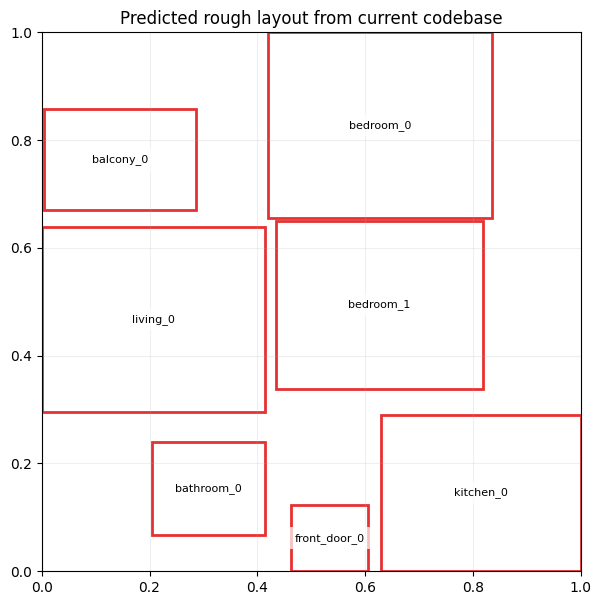

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

for box, color, label in [
    (predicted_boxes_norm, "#e41a1c", "predicted"),
]:
    for cx, cy, w, h in box:
        x0 = cx - w / 2
        y0 = cy - h / 2
        rect = plt.Rectangle(
            (x0, y0),
            w,
            h,
            fill=False,
            edgecolor=color,
            linewidth=2,
            alpha=0.9,
        )
        ax.add_patch(rect)

for idx, node in enumerate(graph.nodes):
    ax.text(
        predicted_boxes_norm[idx, 0],
        predicted_boxes_norm[idx, 1],
        node.id,
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_title("Predicted rough layout from current codebase")
ax.grid(True, alpha=0.2)
plt.show()

In [35]:
# Debug: list violated edges using the same logic as disconnected_edge_count/mean_topology_gap.
id_to_idx = {n.id: i for i, n in enumerate(graph.nodes)}
violations = []
tol = 1e-4

for e in graph.edges:
    i = id_to_idx[e.src]
    j = id_to_idx[e.dst]
    dx = predicted_boxes[j, 0] - predicted_boxes[i, 0]
    dy = predicted_boxes[j, 1] - predicted_boxes[i, 1]
    req_x = 0.5 * (predicted_boxes[i, 2] + predicted_boxes[j, 2])
    req_y = 0.5 * (predicted_boxes[i, 3] + predicted_boxes[j, 3])

    violated = False
    gap = 0.0
    if e.direction == 'left_of':
        violated = dx < req_x - tol
        gap = max(0.0, req_x - dx)
    elif e.direction == 'right_of':
        violated = dx > -req_x + tol
        gap = max(0.0, dx + req_x)
    elif e.direction == 'above':
        violated = dy > -req_y + tol
        gap = max(0.0, dy + req_y)
    elif e.direction == 'below':
        violated = dy < req_y - tol
        gap = max(0.0, req_y - dy)
    else:
        violated = (abs(dx) > req_x and abs(dy) > req_y)
        gap = min(max(0.0, abs(dx) - req_x), max(0.0, abs(dy) - req_y))

    if violated:
        violations.append((e.src, e.dst, e.direction, float(gap), float(dx), float(dy), float(req_x), float(req_y)))

print('Violated edges:', len(violations))
for v in violations:
    print(v)

Violated edges: 4
('front_door_0', 'living_0', 'left_of', 0.49668779969215393, -0.267841637134552, 0.4010487496852875, 0.22884616255760193, 0.2305661141872406)
('kitchen_0', 'living_0', None, 0.005000025033950806, -0.4989798069000244, 0.3176507353782654, 0.32174330949783325, 0.3126507103443146)
('bedroom_0', 'living_0', None, 0.004999995231628418, -0.3449999988079071, -0.35593992471694946, 0.3400000035762787, 0.3400000035762787)
('bathroom_0', 'bedroom_0', None, 0.004999995231628418, 0.2613663077354431, 0.6657670140266418, 0.2563663125038147, 0.25557127594947815)
